## GROUP 6 CAPSTONE PROJECT

# Introduction
In Kenya, Treasury Bills (especially the 91-day T-Bill) are a key investment and signal short-term interest rate trends. However, predicting T-Bill rates is difficult because they depend on many changing economic factors like inflation, CBK policy, exchange rates, and liquidity. Currently, only large institutions with expensive tools (e.g., Bloomberg) can effectively analyze these factors, leaving smaller investors, SACCOs, and businesses at a disadvantage. This creates risks such as costly borrowing and crowding out of private investment.

Despite improved data availability from CBK and KNBS, there is still no free, accessible forecasting tool. Previous studies also show that traditional forecasting methods perform poorly in Kenya’s fast-changing economy.

# Problem statement

This project aims to bridge that gap by building a machine learning model to predict the 91-day T-Bill rate using public economic data. The goal is to provide accurate, transparent, and easy-to-use forecasts, empowering all market participants—not just financial elites—to make better investment decisions.

# General Objective
To develop a machine learning-based system that accurately forecasts the 91-Day Kenyan Treasury Bill weighted average rate.

# Specific Objectives
* Automated Data Pipeline: Build a fully automated system to extract, clean, and store macroeconomic and market data from public sources.
* Feature Engineering: Construct informative variables, including lagged indicators, macroeconomic spreads, and volatility measures.
* Model Development and Evaluation: Train and compare various machine learning models to determine the most accurate approach.
* System Deployment: Create a REST API and a web-based dashboard for delivering forecasts to end users in an accessible format.


In [1]:
#importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import joblib 


Loading and cleaning the datasets for use

In [2]:
dfAnnual_gdp = pd.read_csv('Annual GDP.csv', delimiter=",")

dfAnnual_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              10 non-null     int64  
 1   Nominal GDP prices (Ksh Million)  10 non-null     object 
 2   Annual GDP growth (%)             10 non-null     float64
 3   Real GDP prices (Ksh Million)     10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 452.0+ bytes


In [3]:
dfAnnual_gdp.head()

,Year,Nominal GDP prices (Ksh Million),Annual GDP growth (%),Real GDP prices (Ksh Million)
0,2015,"6,884,317",5.0,"7,287,024"
1,2016,"7,594,064",4.2,"7,594,064"
2,2017,"8,483,396",3.8,"7,885,521"
3,2018,"9,340,307",5.6,"8,330,891"
4,2019,"10,237,727",5.1,"8,756,946"


In [4]:
dfCBR = pd.read_csv("DATASETS\Central Bank Rate (CBR)  .csv", delimiter=",")

dfCBR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    71 non-null     object 
 1   Rate    71 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\1048339993.py:1: SyntaxWarning: invalid escape sequence '\C'
  dfCBR = pd.read_csv("DATASETS\Central Bank Rate (CBR)  .csv", delimiter=",")


In [5]:
dfCBR.head()

,Date,Rate
0,12/08/2025,9.50
1,10/06/2025,9.75
2,08/04/2025,10.00
3,05/02/2025,10.75
4,05/12/2024,11.25


### Cleaning Bank Rate(CBR) .csv

In [6]:
# Convert Date column with explicit day-first format
dfCBR['Date'] = pd.to_datetime(dfCBR['Date'], format='%d/%m/%Y', errors='coerce')

# Sort by Date
dfCBR = dfCBR.sort_values('Date').reset_index(drop=True)

# Create cleaned copy
dfCBR_clean = dfCBR.copy()

# Add Year and Month for merging
dfCBR_clean['Year'] = dfCBR_clean['Date'].dt.year
dfCBR_clean['Month'] = dfCBR_clean['Date'].dt.month_name()

dfCBR_clean.head()



,Date,Rate,Year,Month
0,2015-01-14,8.5,2015,January
1,2015-02-26,8.5,2015,February
2,2015-05-06,8.5,2015,May
3,2015-06-09,10.0,2015,June
4,2015-07-07,11.5,2015,July


In [7]:
dfCBR_clean

,Date,Rate,Year,Month
0,2015-01-14,8.50,2015,January
1,2015-02-26,8.50,2015,February
2,2015-05-06,8.50,2015,May
3,2015-06-09,10.00,2015,June
4,2015-07-07,11.50,2015,July
...,...,...,...,...
66,2024-12-05,11.25,2024,December
67,2025-02-05,10.75,2025,February
68,2025-04-08,10.00,2025,April
69,2025-06-10,9.75,2025,June


In [8]:
# splitting year and month from date column
dfCBR_clean['Year'] = dfCBR_clean['Date'].dt.year
dfCBR_clean['Month'] = dfCBR_clean['Date'].dt.month_name() 
dfCBR_clean.head()

,Date,Rate,Year,Month
0,2015-01-14,8.5,2015,January
1,2015-02-26,8.5,2015,February
2,2015-05-06,8.5,2015,May
3,2015-06-09,10.0,2015,June
4,2015-07-07,11.5,2015,July


In [9]:
#converting it to csv
dfCBR_clean.to_csv("CBR_cleaned.csv", index=False)

### Cleaning Inflation Rates csv

In [10]:
df_inflation = pd.read_csv('DATASETS\Inflation Rates.csv')

df_inflation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      129 non-null    int64  
 1   Month                     129 non-null    object 
 2   Annual Average Inflation  129 non-null    float64
 3   12-Month Inflation        129 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 4.2+ KB


<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\1878011214.py:1: SyntaxWarning: invalid escape sequence '\I'
  df_inflation = pd.read_csv('DATASETS\Inflation Rates.csv')


In [11]:
df_inflation.head()

,Year,Month,Annual Average Inflation,12-Month Inflation
0,2025,August,3.56,4.53
1,2025,July,3.55,4.15
2,2025,June,3.56,3.82
3,2025,May,3.63,3.75
4,2025,April,3.74,4.11


In [12]:
# Standardize column names
df_inflation.columns = (
    df_inflation.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

# Make a copy for cleaning
df_inflation_clean = df_inflation.copy()

# Clean month names (capitalize approprately)
if "month" in df_inflation_clean.columns:
    df_inflation_clean["month"] = (
        df_inflation_clean["month"].astype(str).str.strip().str.capitalize()
    )

# Convert inflation columns to numeric
for col in df_inflation_clean.columns:
    if "inflation" in col:
        df_inflation_clean[col] = pd.to_numeric(df_inflation_clean[col], errors="coerce")

# Create a proper date column (if year & month exist)
if {"year", "month"}.issubset(df_inflation_clean.columns):
    df_inflation_clean["date"] = pd.to_datetime(
        df_inflation_clean["year"].astype(str) + "-" + df_inflation_clean["month"].astype(str) + "-01",
        errors="coerce"
    )

# Drop duplicates
df_inflation_clean = df_inflation_clean.drop_duplicates()

# Reset index
df_inflation_clean = df_inflation_clean.reset_index(drop=True)

# Preview cleaned dataset
print(df_inflation_clean.head())
print(df_inflation_clean.info())

# Save cleaned copy
df_inflation_clean.to_csv("inflation_cleaned.csv", index=False)


   year   month  annual_average_inflation  12month_inflation       date
0  2025  August                      3.56               4.53 2025-08-01
1  2025    July                      3.55               4.15 2025-07-01
2  2025    June                      3.56               3.82 2025-06-01
3  2025     May                      3.63               3.75 2025-05-01
4  2025   April                      3.74               4.11 2025-04-01
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   year                      128 non-null    int64         
 1   month                     128 non-null    object        
 2   annual_average_inflation  128 non-null    float64       
 3   12month_inflation         128 non-null    float64       
 4   date                      128 non-null    datetime64[ns]
dtypes: datetime64[ns](1), flo

In [13]:
df_inflation_clean

,year,month,annual_average_inflation,12month_inflation,date
0,2025,August,3.56,4.53,2025-08-01
1,2025,July,3.55,4.15,2025-07-01
2,2025,June,3.56,3.82,2025-06-01
3,2025,May,3.63,3.75,2025-05-01
4,2025,April,3.74,4.11,2025-04-01
...,...,...,...,...,...
123,2015,May,6.65,6.87,2015-05-01
124,2015,April,6.69,7.08,2015-04-01
125,2015,March,6.63,6.31,2015-03-01
126,2015,February,6.63,5.61,2015-02-01


### Cleaning Issues of Treasury Bills.csv

In [14]:
# Load dataset 
tbills_df = pd.read_csv("DATASETS\Issues of Treasury Bills.csv", skiprows=2)

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\3210043215.py:2: SyntaxWarning: invalid escape sequence '\I'
  tbills_df = pd.read_csv("DATASETS\Issues of Treasury Bills.csv", skiprows=2)


In [15]:
print(tbills_df.columns.tolist())


['Year/Month', 'Total amount offered (Primary market)', 'Tenure', 'Amount allotted', 'Amount rejected', 'Amount redeemed', 'Amount outstanding', 'Unnamed: 7']


In [16]:
for col in tbills_df.columns:
    print(repr(col))

'Year/Month'
'Total amount offered (Primary market)'
'Tenure'
'Amount allotted'
'Amount rejected'
'Amount redeemed'
'Amount outstanding'
'Unnamed: 7'


In [17]:

# Clean column names
tbills_df.columns = tbills_df.columns.str.strip()

# Keep only relevant columns (use the correct column name)
tbills_clean = tbills_df[[
    "Year/Month",
    "Tenure",
    "Amount allotted",
    "Amount redeemed",
]].copy()

# Extract Year and Month separately
tbills_clean.loc[:, "Year"] = tbills_clean["Year/Month"].astype(str).where(
    tbills_clean["Year/Month"].astype(str).str.isnumeric()
)
tbills_clean.loc[:, "Year"] = tbills_clean["Year"].ffill()

tbills_clean.loc[:, "Month"] = tbills_clean["Year/Month"].astype(str).where(
    tbills_clean["Year/Month"].astype(str).str.isalpha()
)
tbills_clean.loc[:, "Month"] = tbills_clean["Month"].ffill()

# Drop the old mixed column
tbills_clean = tbills_clean.drop(columns=["Year/Month"])

print(tbills_clean.head(15))


   Tenure Amount allotted Amount redeemed  Year      Month
0     NaN             NaN             NaN  2000        NaN
1     182        13649.15          6412.1  2000      March
2      91       112307.45       109979.15  2000        nan
3     182          8903.5         5767.28  2000       June
4      91        108476.8       111808.34  2000        nan
5     182           13100        13649.15  2000  September
6      91        109669.2        108476.5  2000        nan
7     182            6054          8903.5  2000   December
8     NaN             NaN             NaN  2000        nan
9     NaN             NaN             NaN  2001        nan
10    182         17240.8           13100  2001      March
11     91       112713.65       110506.35  2001        nan
12    182        10760.15            9054  2001       June
13     91        109539.1       112713.65  2001        nan
14    182         19036.6         17240.8  2001  September


In [18]:
tbills_clean

,Tenure,Amount allotted,Amount redeemed,Year,Month
0,NaN,NaN,NaN,2000,NaN
1,182,13649.15,6412.1,2000,March
2,91,112307.45,109979.15,2000,nan
3,182,8903.5,5767.28,2000,June
4,91,108476.8,111808.34,2000,nan
...,...,...,...,...,...
951,Repo,0,0,2025,nan
952,182,36257.8,58795.95,2025,nan
953,91,25269.95,19035.6,2025,May
954,365,83900.75,51489.4,2025,nan


In [19]:
# filtering to remain with data from 2015 onwards

tbills_clean = tbills_clean[~tbills_clean['Year'].astype(str).isin([str(y) for y in range(2000, 2015)])].reset_index(drop=True)

tbills_clean.tail()

,Tenure,Amount allotted,Amount redeemed,Year,Month
496,Repo,0,0,2025,nan
497,182,36257.8,58795.95,2025,nan
498,91,25269.95,19035.6,2025,May
499,365,83900.75,51489.4,2025,nan
500,Repo,0,0,2025,nan


In [20]:
# to remain with only 91 day tenure
tbills_clean = tbills_clean[tbills_clean['Tenure'].astype(str).str.strip().str.lower().isin(['91', '91 days'])].reset_index(drop=True)

In [21]:
tbills_clean.head(10)

,Tenure,Amount allotted,Amount redeemed,Year,Month
0,91,"8,734.15","7,825.90",2015,January
1,91,"6,154.95","12,268.65",2015,nan
2,91,"10,870.70","7,081.85",2015,nan
3,91,"5,729.80","8,734.15",2015,nan
4,91,"5,199.20","6,154.95",2015,nan
5,91,"7,625.25","10,870.70",2015,nan
6,91,"7,075.30","5,729.80",2015,nan
7,91,"8,512.50","5,922.00",2015,nan
8,91,"17,404.15","6,902.45",2015,nan
9,91,"48,103.00","7,075.30",2015,nan


In [22]:
tbills_clean.isnull().sum()

Tenure             0
Amount allotted    0
Amount redeemed    0
Year               0
Month              0
dtype: int64

In [23]:
tbills_clean_df = pd.read_csv("tbills_cleaned.csv")
tbills_clean_df.head()

,Tenure,Amount allotted,Amount redeemed,Year,Month
0,91,"8,734.15","7,825.90",2015,January
1,91,"6,154.95","12,268.65",2015,February
2,91,"10,870.70","7,081.85",2015,March
3,91,"5,729.80","8,734.15",2015,April
4,91,"5,199.20","6,154.95",2015,May


# Cleaning Trade weighted average rate

In [24]:
df_trade = pd.read_csv('DATASETS\TRADE WEIGHTED AVERAGE INDICATIVE RATES.csv')

df_trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8925 entries, 0 to 8924
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           8925 non-null   object 
 1   Currency       8925 non-null   object 
 2   EXCHANGE RATE  8925 non-null   float64
dtypes: float64(1), object(2)
memory usage: 209.3+ KB


<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\2120814021.py:1: SyntaxWarning: invalid escape sequence '\T'
  df_trade = pd.read_csv('DATASETS\TRADE WEIGHTED AVERAGE INDICATIVE RATES.csv')


In [25]:
df_trade

,Date,Currency,EXCHANGE RATE
0,17/09/2025,US DOLLAR,129.2389
1,17/09/2025,STG POUND,176.4951
2,17/09/2025,EURO,152.8185
3,17/09/2025,SA RAND,7.4380
4,17/09/2025,KES / USHS,27.0816
...,...,...,...
8920,05/01/2024,HONGKONG DOLLAR,20.2221
8921,05/01/2024,SINGAPORE DOLLAR,118.8165
8922,05/01/2024,SAUDI RIYAL,42.1025
8923,05/01/2024,CHINESE YUAN,22.0754


In [26]:
# remaining with only US DOLLAR data
df_trade = df_trade[df_trade['Currency'].str.strip().str.upper() == 'US DOLLAR'].reset_index(drop=True)
df_trade.head()

,Date,Currency,EXCHANGE RATE
0,17/09/2025,US DOLLAR,129.2389
1,16/09/2025,US DOLLAR,129.2400
2,15/09/2025,US DOLLAR,129.2400
3,12/09/2025,US DOLLAR,129.2400
4,11/09/2025,US DOLLAR,129.2402


In [27]:
# average dollar rate per month

# Convert 'Date' to datetime if not already
df_trade['Date'] = pd.to_datetime(df_trade['Date'], format='%d/%m/%Y', errors='coerce')

# Extract Year and Month
df_trade['Year'] = df_trade['Date'].dt.year
df_trade['Month'] = df_trade['Date'].dt.month_name()

# Group by Year and Month, then calculate the mean for numeric columns
df_trade_monthly_avg = df_trade.groupby(['Year', 'Month'], as_index=False).mean(numeric_only=True)

df_trade_monthly_avg.head()


,Year,Month,EXCHANGE RATE
0,2024,April,131.569680
1,2024,August,129.323291
2,2024,December,129.363237
3,2024,February,151.839943
4,2024,January,160.082563


In [28]:
df_trade_monthly_avg.tail()

,Year,Month,EXCHANGE RATE
16,2025,July,129.244039
17,2025,June,129.252763
18,2025,March,129.334805
19,2025,May,129.268262
20,2025,September,129.239731


Joining two datasets to have a large complete one

In [29]:
# Ensure both dataframes cover all months from Jan 2015 to Dec 2025
import pandas as pd

# Create a full range of Year and Month combinations
full_range = pd.date_range(start='2015-01-01', end='2025-12-01', freq='MS')
full_df = pd.DataFrame({
    'Year': full_range.year,
    'Month': full_range.strftime('%B')
})

# Merge the full range with your monthly averages
df_trade_monthly_full = pd.merge(
    full_df,
    df_trade_monthly_avg,
    on=['Year', 'Month'],
    how='left'
)

df_exchange = pd.read_csv("DATASETS\Monthly Exchange rate (period average).csv")

df_exchange.columns = df_exchange.columns.str.strip().str.lower()

# Convert df_exchange 'month' from int to month name string to match full_df
if pd.api.types.is_integer_dtype(df_exchange['month']):
    df_exchange['month'] = df_exchange['month'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%B'))

# Merge the full range with your exchange rates
df_exchange_full = pd.merge(
    full_df,
    df_exchange,
    left_on=['Year', 'Month'],
    right_on=['year', 'month'],
    how='left'
)

# Now merge both together to get a complete dataframe for all months
df_trade_monthly_merged = pd.merge(
    df_trade_monthly_full,
    df_exchange_full.drop(columns=['Year', 'Month']),  # avoid duplicate columns
    left_index=True,
    right_index=True,
    how='left'
)

df_trade_monthly_merged.head(15)

<>:19: SyntaxWarning: invalid escape sequence '\M'
<>:19: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\723751581.py:19: SyntaxWarning: invalid escape sequence '\M'
  df_exchange = pd.read_csv("DATASETS\Monthly Exchange rate (period average).csv")


,Year,Month,EXCHANGE RATE,year,month,exchange rate
0,2015,January,NaN,2015.0,January,91.36
1,2015,February,NaN,2015.0,February,91.49
2,2015,March,NaN,2015.0,March,91.73
3,2015,April,NaN,2015.0,April,93.44
4,2015,May,NaN,2015.0,May,96.39
5,2015,June,NaN,2015.0,June,97.71
6,2015,July,NaN,2015.0,July,101.20
7,2015,August,NaN,2015.0,August,102.43
8,2015,September,NaN,2015.0,September,105.28
9,2015,October,NaN,2015.0,October,102.78


In [30]:
# drop columns 
df_trade_monthly_merged = df_trade_monthly_merged.drop(columns=['EXCHANGE RATE', 'year', 'month'])


In [31]:
df_trade_monthly_merged.head()

,Year,Month,exchange rate
0,2015,January,91.36
1,2015,February,91.49
2,2015,March,91.73
3,2015,April,93.44
4,2015,May,96.39


In [32]:
#converting to csv
df_trade_monthly_merged.to_csv("trade_exchange_rate_merged.csv", index=False)

# Cleaning 91-day Tbill avg rates

In [33]:
df_91days = pd.read_csv('DATASETS\91 days Treasury Bills Average Rates -since 2015.csv')

df_91days.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Issue Date          610 non-null    object 
 1   Issue No            610 non-null    int64  
 2   Tenor               610 non-null    int64  
 3   91 day T-bill Rate  610 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 19.2+ KB


<>:1: SyntaxWarning: invalid escape sequence '\9'
<>:1: SyntaxWarning: invalid escape sequence '\9'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\4119475998.py:1: SyntaxWarning: invalid escape sequence '\9'
  df_91days = pd.read_csv('DATASETS\91 days Treasury Bills Average Rates -since 2015.csv')


In [34]:
df_91days.head()

,Issue Date,Issue No,Tenor,91 day T-bill Rate
0,13/01/2025,2612,91,9.5935
1,06/01/2025,2611,91,9.8252
2,30/12/2024,2610,91,9.8946
3,23/12/2024,2609,91,9.9546
4,16/12/2024,2608,91,10.0311


In [35]:
df_91days['Issue Date'] = pd.to_datetime(df_91days['Issue Date'], format='%d/%m/%Y')
df_91days['Issue Date'] = pd.to_datetime(df_91days['Issue Date'], errors='coerce')
df_91days.set_index('Issue Date', inplace=True)
df_91days = df_91days[['91 day T-bill Rate']]
df_91days.head(10) 


,91 day T-bill Rate
Issue Date,
2025-01-13,9.5935
2025-01-06,9.8252
2024-12-30,9.8946
2024-12-23,9.9546
2024-12-16,10.0311
2024-12-09,10.4564
2024-12-02,11.2500
2024-11-25,12.0340
2024-11-18,12.7905


This code checks if the `'Issue Date'` column exists in the `df_91days` DataFrame. If it does, it sets `'Issue Date'` as the DataFrame's index. This is important for time series operations, such as resampling or grouping by date, and helps ensure that subsequent date-based analyses work correctly.

In [36]:
# Ensuring 'Issue Date' is the index
if 'Issue Date' in df_91days.columns:
    df_91days.set_index('Issue Date', inplace=True)

In [37]:
if 'Issue Date' not in df_91days.columns:
    df_91days = df_91days.reset_index()
df_91days['Issue Date'] = pd.to_datetime(df_91days['Issue Date'], errors='coerce')
df_91days.set_index('Issue Date', inplace=True)

Monthly Aggregation Data Cleaning Explanation on the 91days dataframe.

Cleaning our DataFrame by converting the 'Issue Date' column to a datetime format and setting it as the index. Then resampled the data by month and calculated the average of the 'Weighted Average Rate' for each month. This process combines all records from the same month into a single monthly average, resulting in one row per month in our new DataFrame. This is useful for analyzing trends on a monthly basis and removing duplicate or multiple readings within the same month.

In [38]:
# Ensure 'Issue Date' is a column before converting and setting as index
if 'Issue Date' not in df_91days.columns:
    df_91days = df_91days.reset_index()

df_91days['Issue Date'] = pd.to_datetime(df_91days['Issue Date'], errors='coerce')
df_91days.set_index('Issue Date', inplace=True)

# Keep only the target variable
df_91days = df_91days[['91 day T-bill Rate']]

# Resample by month and calculate the mean
df_91days_monthly = df_91days.resample('M').mean()

# Display the result
df_91days_monthly.head(10)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\1942305743.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_91days_monthly = df_91days.resample('M').mean()


,91 day T-bill Rate
Issue Date,
2015-01-31,8.594286
2015-02-28,8.589250
2015-03-31,8.486000
2015-04-30,8.418000
2015-05-31,8.256500
2015-06-30,8.257800
2015-07-31,10.259000
2015-08-31,11.524333
2015-09-30,14.613250


In [39]:
# splitting the index (which is the date) into year and month
df_91days_monthly['Year'] = df_91days_monthly.index.year
df_91days_monthly['Month'] = df_91days_monthly.index.month_name()
df_91days_monthly.head()

,91 day T-bill Rate,Year,Month
Issue Date,,,
2015-01-31,8.594286,2015,January
2015-02-28,8.589250,2015,February
2015-03-31,8.486000,2015,March
2015-04-30,8.418000,2015,April
2015-05-31,8.256500,2015,May


In [40]:
#converting to csv
df_91days_monthly.to_csv("91days_monthly.csv", index=False)

# Cleaning Public debt

In [41]:
df_public_debt = pd.read_csv('DATASETS\Public Debt.csv')

df_public_debt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               124 non-null    int64 
 1   Month              124 non-null    int64 
 2     Domestic Debt    124 non-null    object
 3     External Debt    124 non-null    object
 4     Total            124 non-null    object
dtypes: int64(2), object(3)
memory usage: 5.0+ KB


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15628\3095866696.py:1: SyntaxWarning: invalid escape sequence '\P'
  df_public_debt = pd.read_csv('DATASETS\Public Debt.csv')


In [42]:
def convert_year_month_to_datetime(df_public_debt, year='Year', month='Month', date="Date"):
    
    # Ensure Year and Month are strings
    df_public_debt[year] = df_public_debt[year].astype(str)
    df_public_debt[month] = df_public_debt[month].astype(str).str.zfill(2)  # pad month like '01', '02', ...

    # Combine into YYYY-MM format and convert to datetime
    df_public_debt[date] = pd.to_datetime(df_public_debt[year] + '-' + df_public_debt[month], format='%Y-%m')
    
    return df_public_debt

In [43]:
df_public_debt = convert_year_month_to_datetime(df_public_debt)

print(df_public_debt)

     Year Month   Domestic Debt     External Debt           Total         Date
0    2015    01     1,334,642.80     1,163,350.79     2,497,993.59  2015-01-01
1    2015    02     1,353,302.65     1,296,748.46     2,650,051.11  2015-02-01
2    2015    03     1,397,125.72     1,278,107.87     2,675,233.59  2015-03-01
3    2015    04     1,415,431.51     1,326,835.19     2,742,266.71  2015-04-01
4    2015    05     1,407,811.19     1,381,156.98     2,788,968.18  2015-05-01
..    ...   ...               ...              ...              ...        ...
119  2024    12     5,868,273.16     5,057,005.78    10,925,278.94  2024-12-01
120  2025    01     5,927,805.27     5,083,403.45    11,011,208.71  2025-01-01
121  2025    02     6,062,699.97     5,071,505.77    11,134,205.74  2025-02-01
122  2025    03     6,126,697.86     5,238,297.33    11,364,995.19  2025-03-01
123  2025    04     6,164,101.75     5,326,268.77    11,490,370.52  2025-04-01

[124 rows x 6 columns]


In [44]:
df_public_debt.columns = df_public_debt.columns.str.strip().str.lower().str.replace(" ", "_") 
df_public_debt.columns   

Index(['year', 'month', 'domestic_debt', 'external_debt', 'total', 'date'], dtype='object')

In [45]:
# Remove commas, strip spaces, then convert to float for each relevant column
for col in ['domestic_debt', 'external_debt', 'total']:
    df_public_debt[col] = (
        df_public_debt[col]
        .astype(str)              
        .str.replace(",", "")     
        .str.strip()              
        .astype(float)            
    )


In [46]:
df_public_debt.head()

,year,month,domestic_debt,external_debt,total,date
0,2015,01,1334642.80,1163350.79,2497993.59,2015-01-01
1,2015,02,1353302.65,1296748.46,2650051.11,2015-02-01
2,2015,03,1397125.72,1278107.87,2675233.59,2015-03-01
3,2015,04,1415431.51,1326835.19,2742266.71,2015-04-01
4,2015,05,1407811.19,1381156.98,2788968.18,2015-05-01


In [47]:
#convert to csv
df_public_debt.to_csv("cleaned_public_debt.csv", index=False)

# --- 1. DATA PREPARATION ---

In [48]:
# loading and working with the new datasets

df_91_1 = pd.read_csv("91days_monthly.csv")
df_annual_gdp_1 = pd.read_csv("Annual GDP.csv")
df_cbr_1 = pd.read_csv("CBR_cleaned.csv")
df_public_debt_1 = pd.read_csv("cleaned_public_debt.csv")
df_inflation_1 = pd.read_csv("inflation_cleaned.csv")
df_trade_exchange_1 = pd.read_csv("trade_exchange_rate_merged.csv")
df_tbills_1 = pd.read_csv("tbills_cleaned.csv")

Merging all the dataframes into one

In [49]:
# Define a list of the filenames to merge
file_names = [
    'Annual GDP.csv',
    '91days_monthly.csv',
    'CBR_cleaned.csv',
    'cleaned_public_debt.csv',
    'inflation_cleaned.csv',
    'tbills_cleaned.csv',
    'trade_exchange_rate_merged.csv'
]

# Create a dictionary to hold dataframes
dfs = {}

# --- Step 1: Read and preprocess each file ---
print("Reading and cleaning datasets...")
for file in file_names:
    print(f"Processing {file}...")
    # Read the CSV file
    df = pd.read_csv(file)

    # Convert all column names to lowercase for consistency
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # Standardize 'month' and 'year' columns to a consistent type
    if 'month' in df.columns:
        # Dictionary to map month names to numbers
        month_mapping = {
            'january': 1, 'february': 2, 'march': 3, 'april': 4,
            'may': 5, 'june': 6, 'july': 7, 'august': 8,
            'september': 9, 'october': 10, 'november': 11, 'december': 12
        }
        
        # Convert month names to numbers if they are strings
        if df['month'].dtype == 'object':
            df['month'] = df['month'].str.lower().map(month_mapping)
    
    # Ensure year and month are of integer type for merging
    if 'year' in df.columns:
        df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    if 'month' in df.columns:
        df['month'] = pd.to_numeric(df['month'], errors='coerce').astype('Int64')

    # Remove commas and convert specific columns to numeric
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                # Check if the column contains commas, and if so, remove them and convert to numeric
                if df[col].str.contains(',').any():
                    df[col] = df[col].str.replace(',', '', regex=False)
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            except Exception:
                # This handles columns that are not meant to be converted to numeric
                pass

    # Store the cleaned DataFrame in the dictionary
    dfs[file] = df

# --- Step 2: Merge the monthly datasets ---
print("\nMerging monthly datasets...")

# Initialize the merged_df with one of the monthly dataframes as a base
monthly_files = [
    '91days_monthly.csv',
    'CBR_cleaned.csv',
    'cleaned_public_debt.csv',
    'inflation_cleaned.csv',
    'tbills_cleaned.csv',
    'trade_exchange_rate_merged.csv'
]

# Ensure the base dataframe has 'year' and 'month' columns
base_df = dfs[monthly_files[0]]
merged_df = base_df.copy()

# Iteratively merge the rest of the monthly dataframes
for file in monthly_files[1:]:
    df_to_merge = dfs[file]
    # Use a left join to keep all rows from the base dataframe
    merged_df = pd.merge(merged_df, df_to_merge, on=['year', 'month'], how='left')

# --- Step 3: Merge the annual GDP data ---
print("Merging annual GDP data")
gdp_df = dfs['Annual GDP.csv']
# Merge the monthly data with the annual GDP data on the 'year' column
# This will duplicate the annual GDP values for each month, which is expected
merged_df = pd.merge(merged_df, gdp_df, on='year', how='left')

# Handle NaN values and fill missing data 
print("\nFilling missing values")

# Fill numerical columns using ffill (forward-fill) and then bfill (backward-fill)
numeric_cols = merged_df.select_dtypes(include=['number']).columns
merged_df[numeric_cols] = merged_df[numeric_cols].ffill().bfill()

# Check for any remaining NaNs in numerical columns (e.g., leading NaNs)
if merged_df[numeric_cols].isnull().values.any():
    print("Warning: Some NaN values remain in numerical columns after ffill/bfill.")
    # For any remaining NaNs, fill with 0
    merged_df[numeric_cols] = merged_df[numeric_cols].fillna(0)

# Fill categorical/object columns with a placeholder
for col in merged_df.select_dtypes(include=['object']).columns:
    merged_df[col] = merged_df[col].fillna('N/A')

# --- Step 5: Verify and save the final dataset ---
print("\nFinal Merged DataFrame Info:")
merged_df.info()

# Save the final merged dataframe to a new CSV file
output_file = 'final_merged_dataset.csv'
merged_df.to_csv(output_file, index=False)

print(f"\nSuccessfully merged all datasets into '{output_file}'.")
print("The final dataset contains no NaN values.")


Reading and cleaning datasets...
Processing Annual GDP.csv...
Processing 91days_monthly.csv...
Processing CBR_cleaned.csv...
Processing cleaned_public_debt.csv...
Processing inflation_cleaned.csv...
Processing tbills_cleaned.csv...
Processing trade_exchange_rate_merged.csv...

Merging monthly datasets...
Merging annual GDP data

Filling missing values

Final Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   91_day_t-bill_rate                123 non-null    float64
 1   year                              123 non-null    Int64  
 2   month                             123 non-null    Int64  
 3   date_x                            123 non-null    object 
 4   rate                              123 non-null    float64
 5   domestic_debt                     123 non-null    float64
 6   ex

In [50]:
merged_df.head()

,91_day_t-bill_rate,year,month,date_x,rate,domestic_debt,external_debt,total,date_y,annual_average_inflation,12month_inflation,date,tenure,amount_allotted,amount_redeemed,exchange_rate,nominal_gdp_prices_(ksh_million),annual_gdp_growth_(%),real_gdp_prices_(ksh_million)
0,8.594286,2015,1,2015-01-14,8.5,1334642.80,1163350.79,2497993.59,2015-01-01,6.74,5.53,2015-01-01,91,8734.15,7825.90,91.36,6884317.0,5.0,7287024.0
1,8.589250,2015,2,2015-02-26,8.5,1353302.65,1296748.46,2650051.11,2015-02-01,6.63,5.61,2015-02-01,91,6154.95,12268.65,91.49,6884317.0,5.0,7287024.0
2,8.486000,2015,3,N/A,8.5,1397125.72,1278107.87,2675233.59,2015-03-01,6.63,6.31,2015-03-01,91,10870.70,7081.85,91.73,6884317.0,5.0,7287024.0
3,8.418000,2015,4,N/A,8.5,1415431.51,1326835.19,2742266.71,2015-04-01,6.69,7.08,2015-04-01,91,5729.80,8734.15,93.44,6884317.0,5.0,7287024.0
4,8.256500,2015,5,2015-05-06,8.5,1407811.19,1381156.98,2788968.18,2015-05-01,6.65,6.87,2015-05-01,91,5199.20,6154.95,96.39,6884317.0,5.0,7287024.0


In [51]:
#dropping columns
merged_df = merged_df.drop(columns=['date_x', 'date_y'])
merged_df.head()

,91_day_t-bill_rate,year,month,rate,domestic_debt,external_debt,total,annual_average_inflation,12month_inflation,date,tenure,amount_allotted,amount_redeemed,exchange_rate,nominal_gdp_prices_(ksh_million),annual_gdp_growth_(%),real_gdp_prices_(ksh_million)
0,8.594286,2015,1,8.5,1334642.80,1163350.79,2497993.59,6.74,5.53,2015-01-01,91,8734.15,7825.90,91.36,6884317.0,5.0,7287024.0
1,8.589250,2015,2,8.5,1353302.65,1296748.46,2650051.11,6.63,5.61,2015-02-01,91,6154.95,12268.65,91.49,6884317.0,5.0,7287024.0
2,8.486000,2015,3,8.5,1397125.72,1278107.87,2675233.59,6.63,6.31,2015-03-01,91,10870.70,7081.85,91.73,6884317.0,5.0,7287024.0
3,8.418000,2015,4,8.5,1415431.51,1326835.19,2742266.71,6.69,7.08,2015-04-01,91,5729.80,8734.15,93.44,6884317.0,5.0,7287024.0
4,8.256500,2015,5,8.5,1407811.19,1381156.98,2788968.18,6.65,6.87,2015-05-01,91,5199.20,6154.95,96.39,6884317.0,5.0,7287024.0


# ---2. EXPLORATORY DATA ANALYSIS---

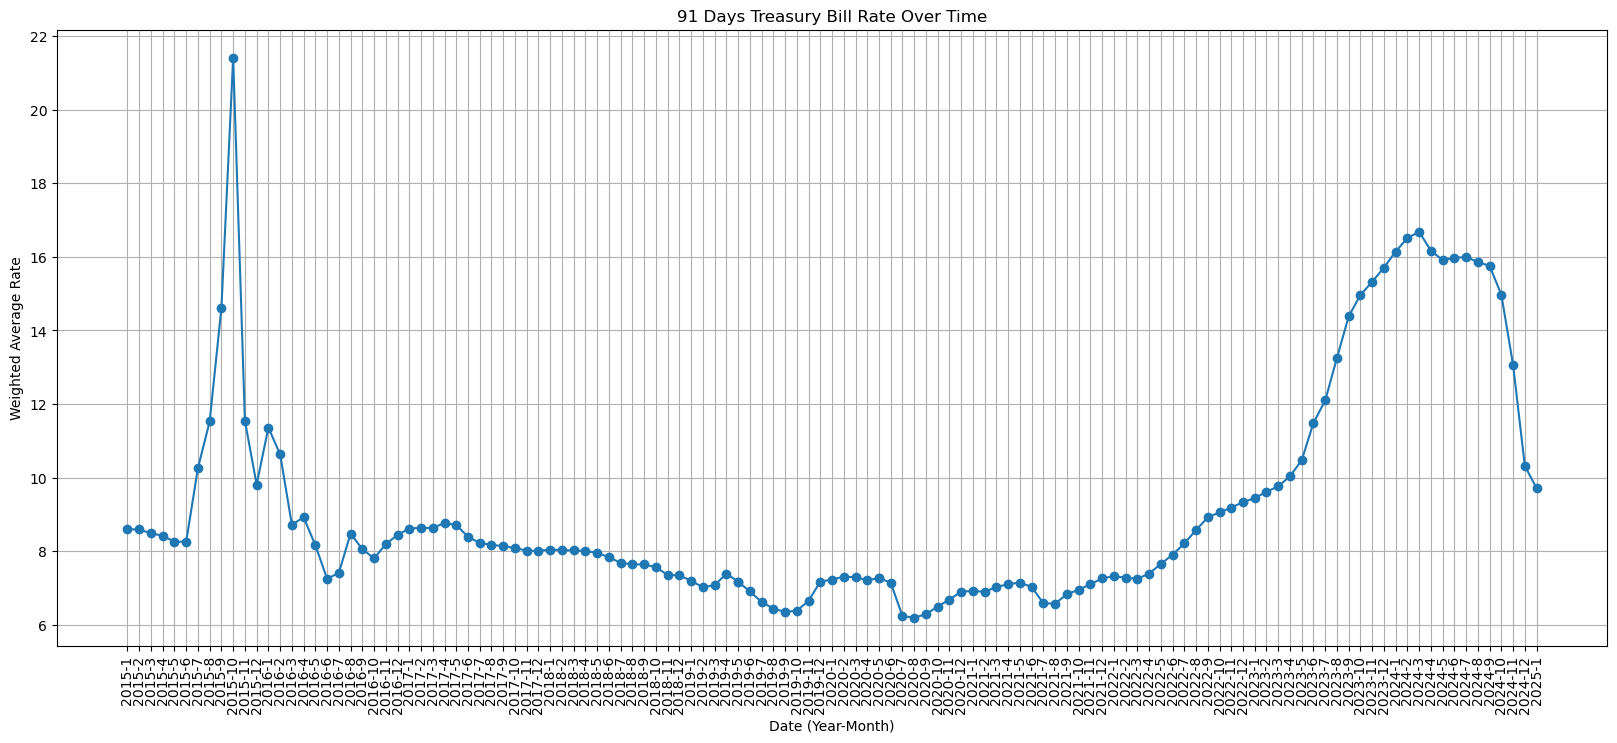

In [52]:
# graphing trends of 91 days treasury bill rate
plt.figure(figsize=(20, 8))
plt.plot(
	merged_df['year'].astype(str) + '-' + merged_df['month'].astype(str),
	merged_df['91_day_t-bill_rate'],
	marker='o'
)
plt.title('91 Days Treasury Bill Rate Over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Weighted Average Rate')
plt.xticks(rotation=90)
plt.grid()
plt.show()


In [53]:
# setting date time as index
merged_df['date'] = pd.to_datetime(merged_df['year'].astype(str) + '-' + merged_df['month'].astype(str) + '-01', errors='coerce')
merged_df.set_index('date', inplace=True)

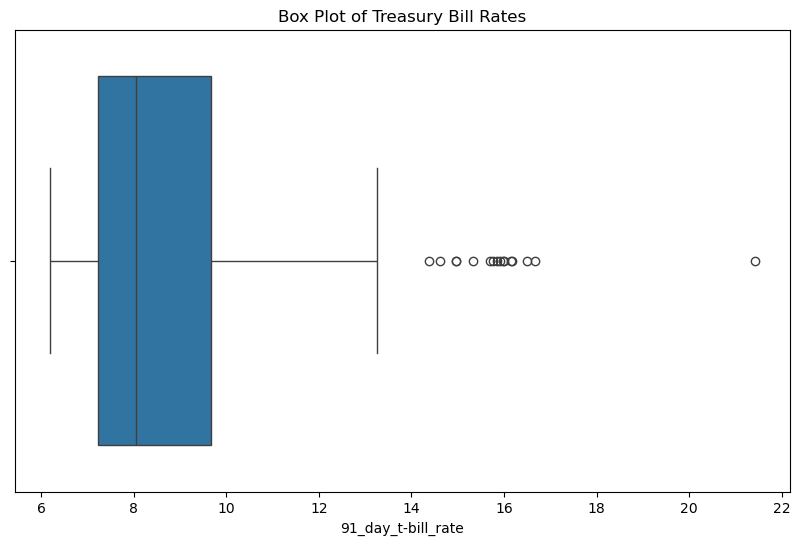

In [54]:
# box plot to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=merged_df['91_day_t-bill_rate'])
plt.title("Box Plot of Treasury Bill Rates")
plt.show()

# --- 3. Statistical analysis ---

In [55]:
merged_df.describe()

,91_day_t-bill_rate,year,month,rate,domestic_debt,external_debt,total,annual_average_inflation,12month_inflation,tenure,amount_allotted,amount_redeemed,exchange_rate,nominal_gdp_prices_(ksh_million),annual_gdp_growth_(%),real_gdp_prices_(ksh_million)
count,123.000000,123.0,123.0,123.000000,1.230000e+02,1.230000e+02,1.230000e+02,123.000000,123.000000,123.0,123.000000,123.00000,123.000000,1.230000e+02,123.000000,1.230000e+02
mean,9.160637,2019.544715,6.430894,9.359756,3.226359e+06,3.351350e+06,6.577709e+06,6.331138,6.164472,91.0,30566.727236,29127.64065,111.664309,1.103692e+07,4.584553,8.929462e+06
std,3.038347,2.892194,3.464294,1.780802,1.297708e+06,1.333694e+06,2.615891e+06,1.158320,1.693811,0.0,25544.823172,25555.70928,14.980467,2.998767e+06,1.941946,1.153401e+06
min,6.194800,2015.0,1.0,7.000000,1.334643e+06,1.163351e+06,2.497994e+06,4.210000,2.720000,91.0,5199.200000,5729.80000,91.360000,6.884317e+06,-0.300000,7.287024e+06
25%,7.219125,2017.0,3.5,7.875000,2.129861e+06,2.307657e+06,4.437518e+06,5.375000,5.000000,91.0,13054.650000,12778.60000,101.495000,8.483396e+06,4.200000,7.885521e+06
50%,8.055250,2020.0,6.0,9.000000,3.003700e+06,3.133543e+06,6.116598e+06,6.290000,5.870000,91.0,20186.050000,19184.90000,103.800000,1.071507e+07,4.900000,8.756946e+06
75%,9.662175,2022.0,9.0,10.500000,4.299512e+06,4.297462e+06,8.594811e+06,6.875000,6.915000,91.0,39010.525000,36969.72500,117.805000,1.348964e+07,5.600000,9.852583e+06
max,21.411222,2025.0,12.0,13.000000,5.927805e+06,6.189967e+06,1.124041e+07,8.780000,11.700000,91.0,117439.050000,117439.05000,159.690000,1.622448e+07,7.600000,1.090828e+07


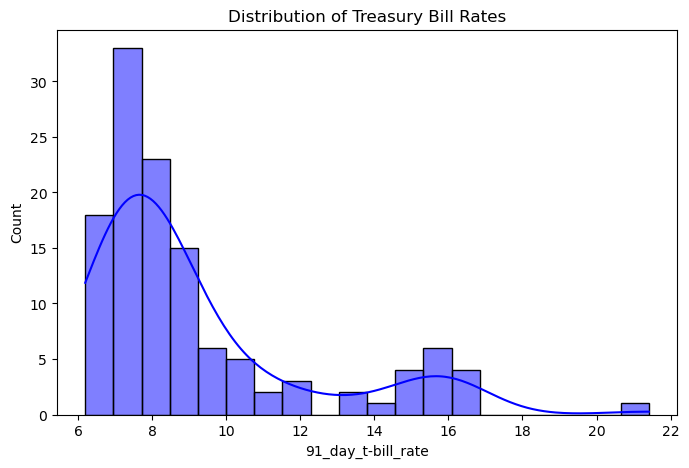

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df['91_day_t-bill_rate'], kde=True, bins=20, color="blue")
plt.title("Distribution of Treasury Bill Rates")
plt.show()

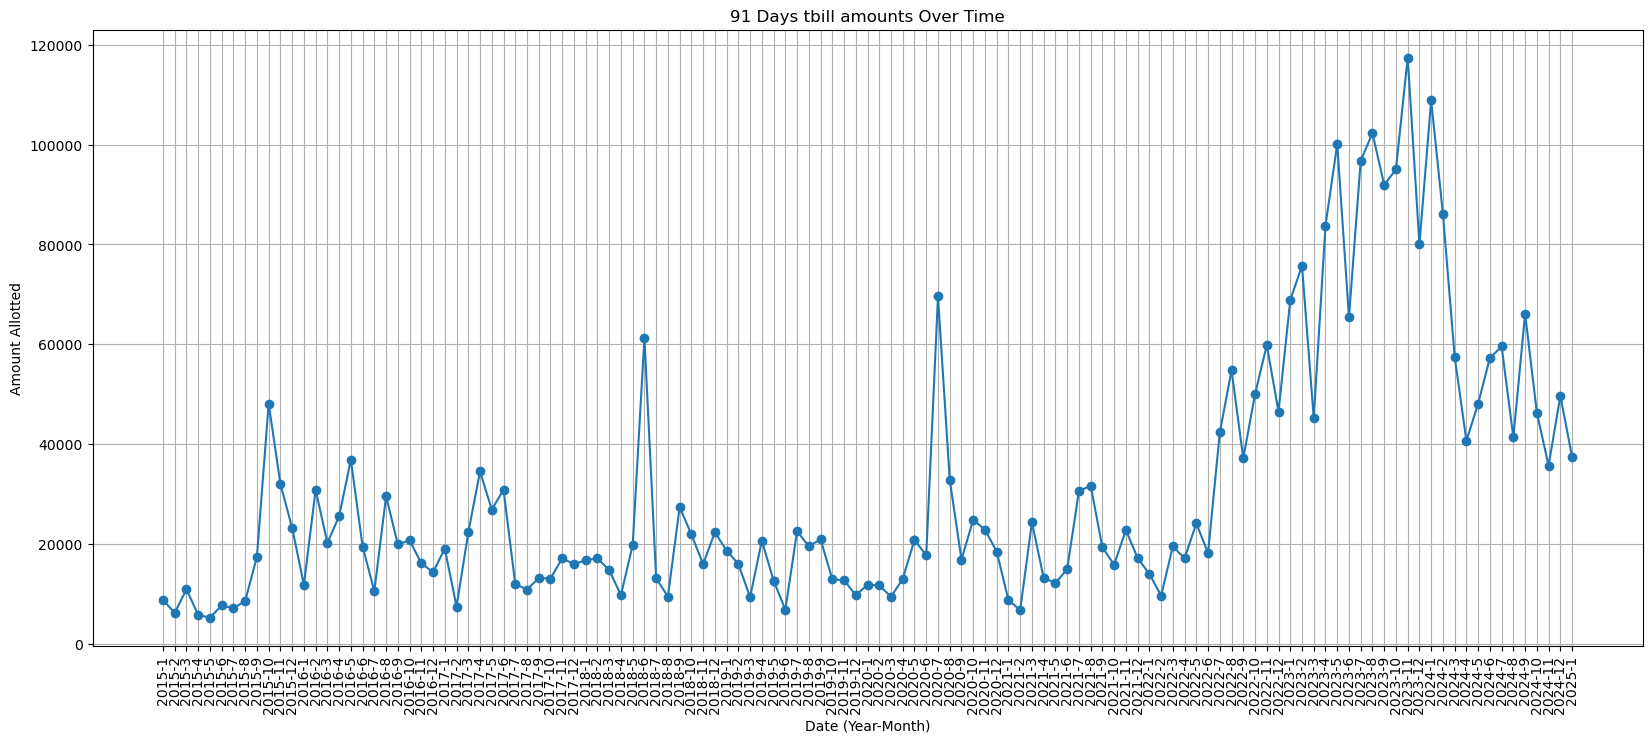

In [57]:
#plotting time vs amount alloted
plt.figure(figsize=(20, 8))
plt.plot(merged_df['year'].astype(str) + '-' + merged_df['month'].astype(str), merged_df['amount_allotted'], marker='o')
plt.title('91 Days tbill amounts Over Time')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Amount Allotted')
plt.xticks(rotation=90)
plt.grid()
plt.show()

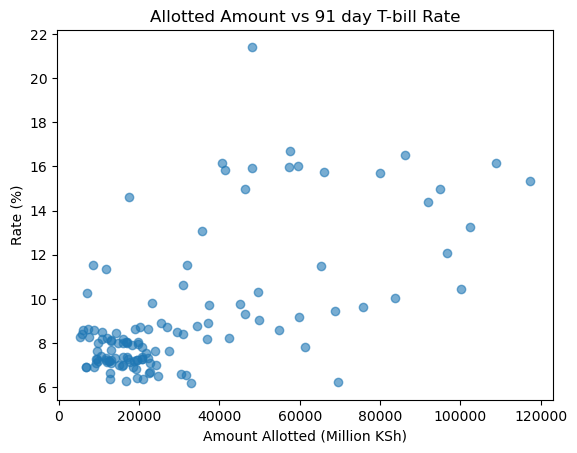

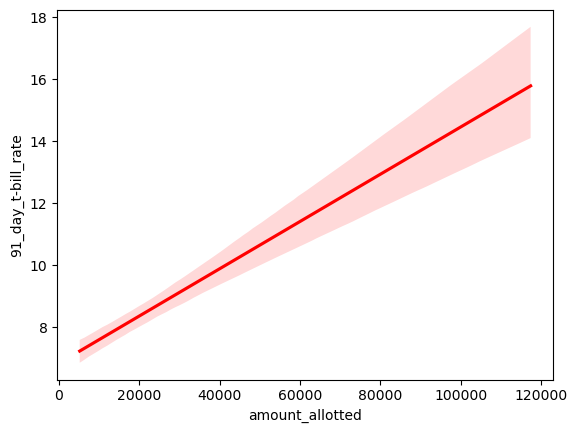

In [58]:
# building a scatter plot to show the correlation between amount allotted and weighted average rate
plt.scatter(merged_df['amount_allotted'], merged_df['91_day_t-bill_rate'], alpha=0.6)
plt.xlabel("Amount Allotted (Million KSh)")
plt.ylabel("Rate (%)")
plt.title("Allotted Amount vs 91 day T-bill Rate")
plt.show()

#draw line of best fit
sns.regplot(x='amount_allotted', y='91_day_t-bill_rate', data=merged_df, scatter=False, color='red')
plt.show()

Output interpretation: When the government has higher allotment values, it suggests more supply of money therefore leading to a higher weighted average rate of return for investors.

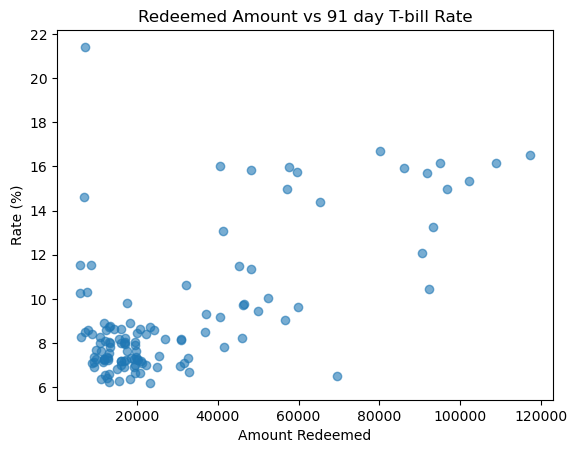

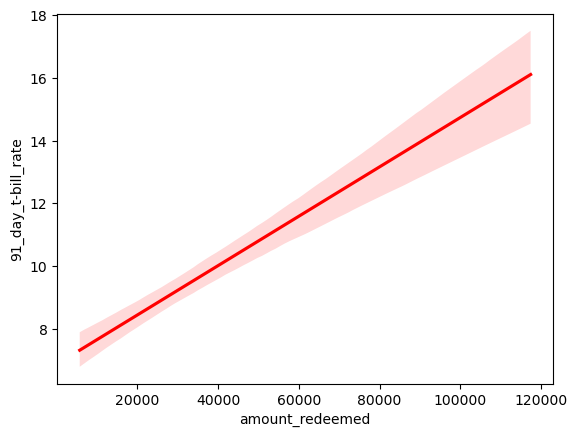

In [59]:
# building a scatter plot to show the correlation between amount redeemed and weighted average rate
plt.scatter(merged_df['amount_redeemed'], merged_df['91_day_t-bill_rate'], alpha=0.6)
plt.xlabel("Amount Redeemed")
plt.ylabel("Rate (%)")
plt.title("Redeemed Amount vs 91 day T-bill Rate")
plt.show()

#plotting line of best fit
sns.regplot(x='amount_redeemed', y='91_day_t-bill_rate', data=merged_df, scatter=False, color='red')
plt.show()


Output interpretation: Amount redeemed refers to the face value of T-Bills that hav matured and the government repaid to investors during a given period. This means that investors have more liquidity and the governemnt would entice them to subscribe to new T-Bills by offering higher interests thus the trend seen above.

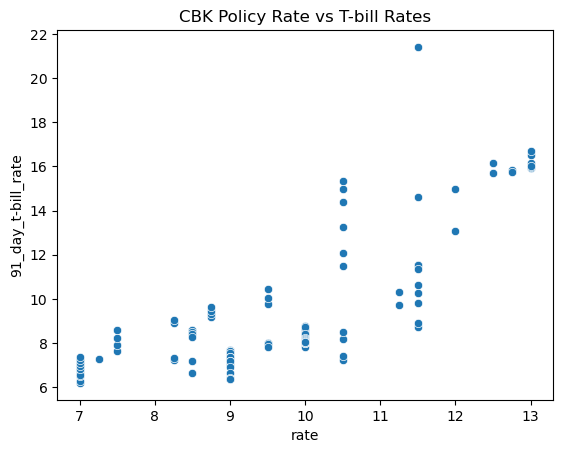

In [60]:
#plotting the correlation between CBK rate and weighted average rate

sns.scatterplot(x='rate', y='91_day_t-bill_rate', data=merged_df)
plt.title("CBK Policy Rate vs T-bill Rates")
plt.show()

Output interpretation: a higher CBK rate leads to a higher weighted average rate for T-bills on the primary market as more people are encouraged to save and discouraged from borrowing.

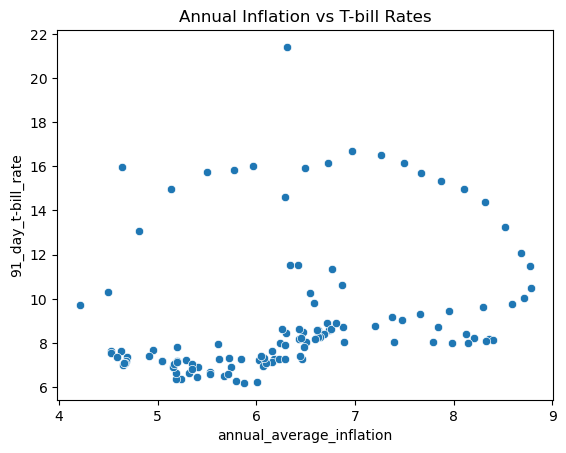

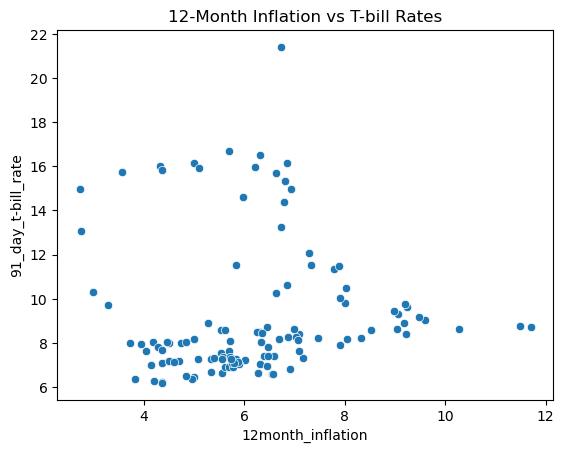

In [61]:
#plotting the correlation between inflation and weighted average rate
sns.scatterplot(x='annual_average_inflation', y='91_day_t-bill_rate', data=merged_df)
plt.title("Annual Inflation vs T-bill Rates")
plt.show()

sns.scatterplot(x='12month_inflation', y='91_day_t-bill_rate', data=merged_df)
plt.title("12-Month Inflation vs T-bill Rates")
plt.show()

Output interpretation: In economics, "12-month inflation" measures the price change between a specific month and the same month of the previous year, while "annual average inflation" compares the average price level of one 12-month period to the average price level of the preceding 12-month period.
Weak correlation: There is no strong upward or downward trend. Inflation does not reliably predict T-bill rates.
In case, inflation does not fully explain T-bill rates in this data. Rates are driven by additional economic and policy factors like: 
* Government borrowing needs.
* Liquidity conditions in the banking sector
* Monetary policy stance
* Investor risk perceptions

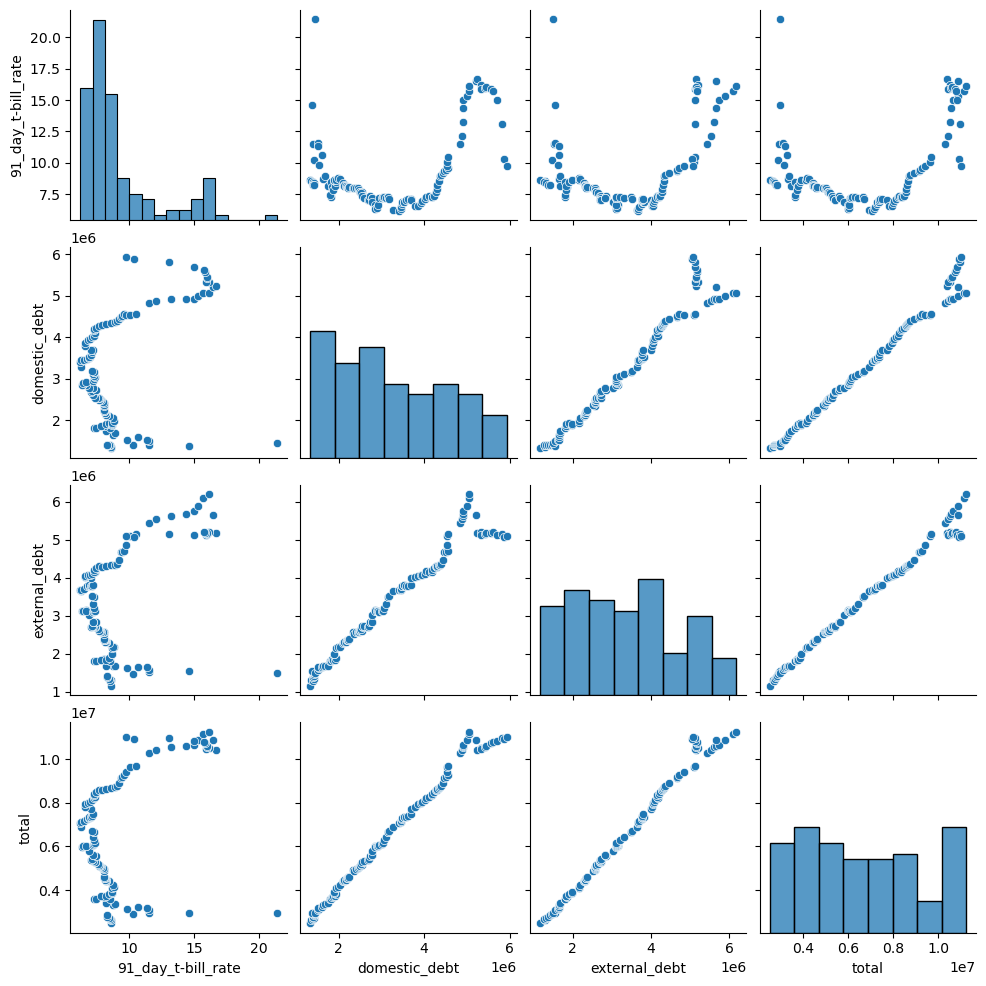

In [62]:
sns.pairplot(merged_df[['91_day_t-bill_rate', 'domestic_debt', 'external_debt', 'total']])

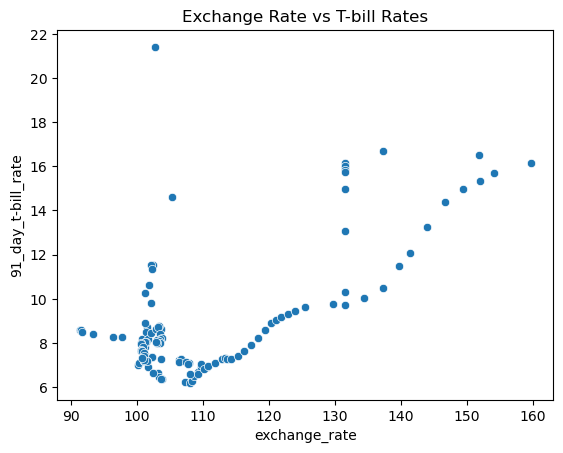

In [63]:
# Ensure both 'month' columns are strings with month names for merging
merged_df_plot = merged_df.reset_index().copy()
# Convert integer month to month name
import calendar
merged_df_plot['month'] = merged_df_plot['month'].apply(lambda x: calendar.month_name[int(x)])

# Prepare exchange rate dataframe for merge
df_trade_monthly_avg_renamed = df_trade_monthly_avg.rename(columns={'Year': 'year', 'Month': 'month'})

# Merge on year and month name
merged_df_plot = merged_df_plot.merge(
	df_trade_monthly_avg_renamed,
	on=['year', 'month'],
	how='left'
)

# Plot the correlation between exchange rate and weighted average rate
sns.scatterplot(
	x='exchange_rate',
	y='91_day_t-bill_rate',
	data=merged_df_plot
)
plt.title("Exchange Rate vs T-bill Rates")
plt.show()

Output interpretation: When the exchange rate between the Kenyan shilling against the US Dollar is high, the weighted average rate of T-bills is seen to also be high. Currency depreciation often coincides with rising yields.

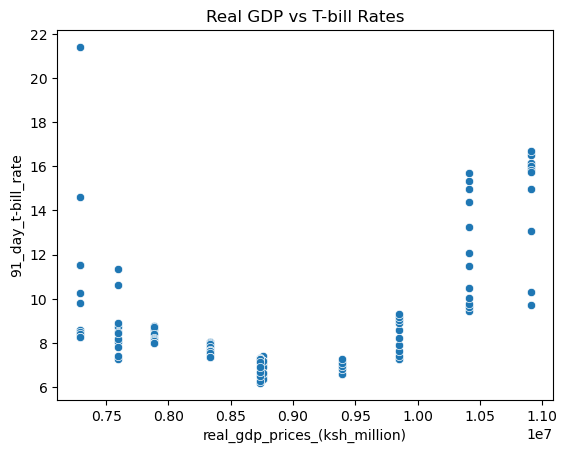

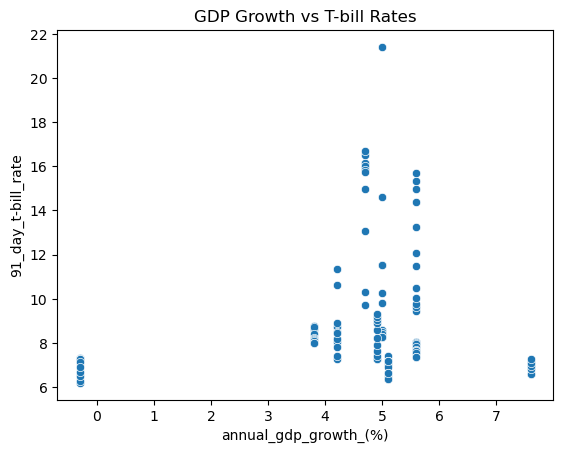

In [64]:
# plotting the correlation between real gdp and weighted average rate
sns.scatterplot(x='real_gdp_prices_(ksh_million)', y='91_day_t-bill_rate', data=merged_df)
plt.title("Real GDP vs T-bill Rates")
plt.show()

#plotting the correlation between annual gdp growth and weighted average rate
sns.scatterplot(x='annual_gdp_growth_(%)', y='91_day_t-bill_rate', data=merged_df)
plt.title("GDP Growth vs T-bill Rates")
plt.show()

Output interpretation: For both cases, as GDP grew, T-bill rates first stabilized at low levels, then climbed again, suggesting that government financing needs outweighed the benefits of stronger growth.

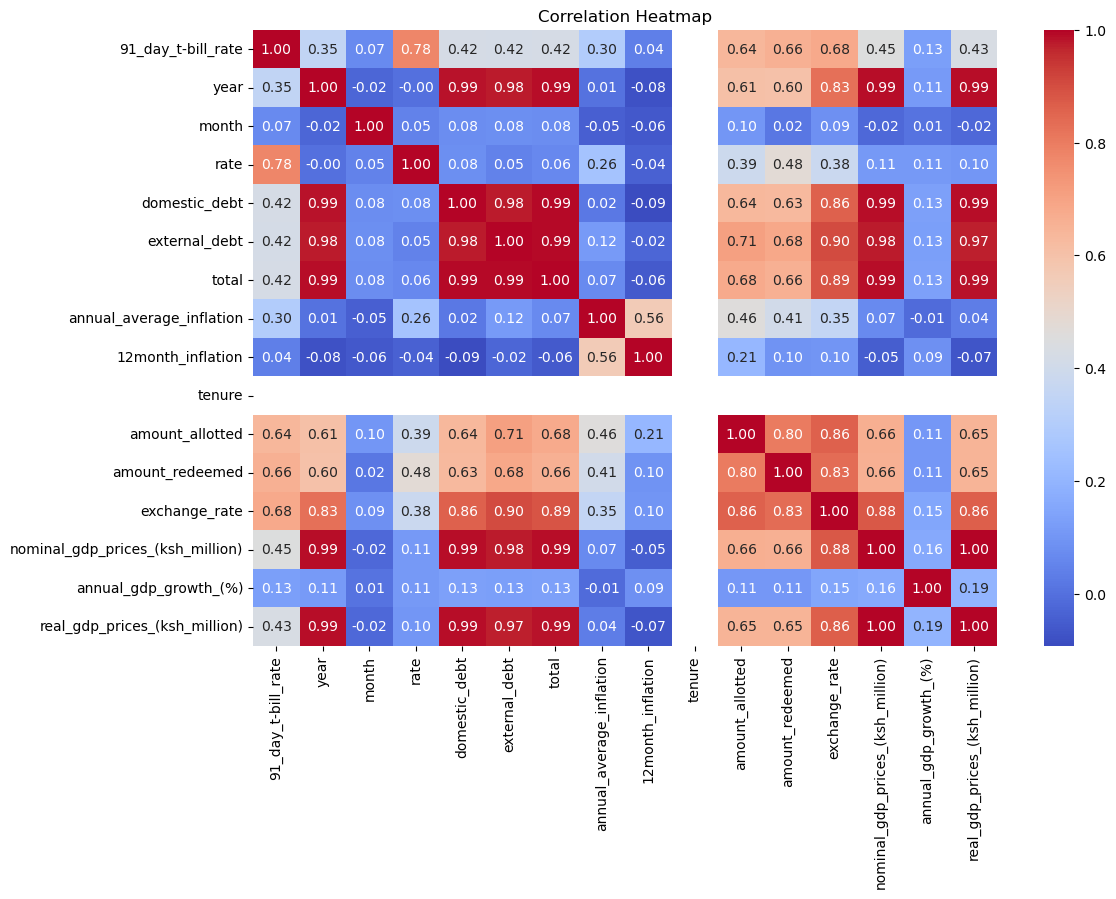

In [65]:
# plotting the correlation heatmap for numeric columns only
numeric_cols = merged_df.select_dtypes(include=['number']).columns
plt.figure(figsize=(12,8))
sns.heatmap(merged_df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

* T-bill rates are driven more by domestic debt issuance and government borrowing levels than by GDP growth or inflation.

* GDP growth is largely uncorrelated with most financial market indicators here, suggesting growth and government financing conditions move independently.

* Exchange rate movements are closely tied to government borrowing (allotments and redemptions) and inversely tied to T-bill rates.

* Inflation seems relatively detached from debt and rates in this dataset, which may imply external or supply-side drivers.

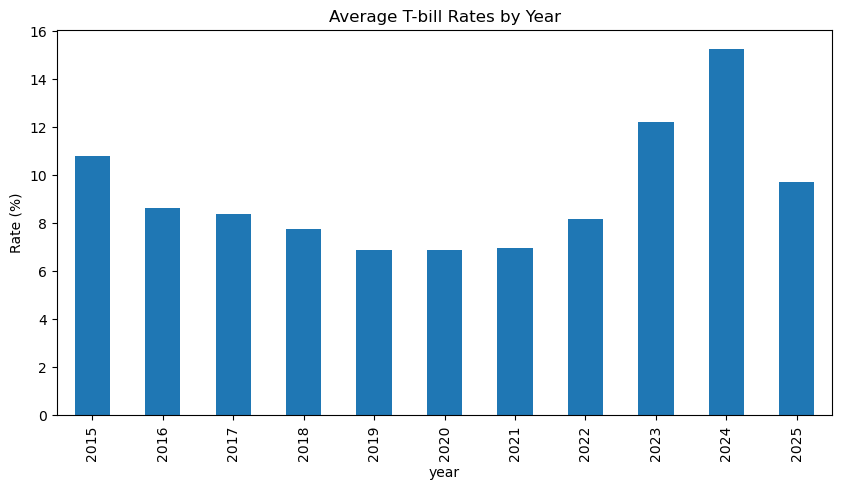

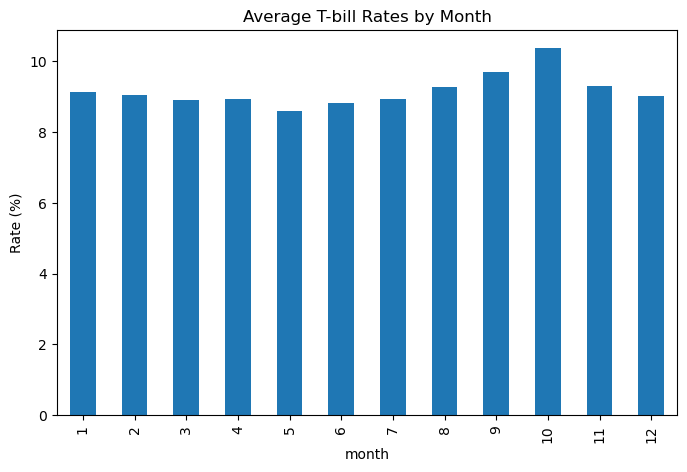

In [66]:
# Yearly trend
merged_df.groupby('year')['91_day_t-bill_rate'].mean().plot(kind='bar', figsize=(10,5))
plt.title("Average T-bill Rates by Year")
plt.ylabel("Rate (%)")
plt.show()

# Monthly seasonality
merged_df.groupby('month')['91_day_t-bill_rate'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average T-bill Rates by Month")
plt.ylabel("Rate (%)")
plt.show()

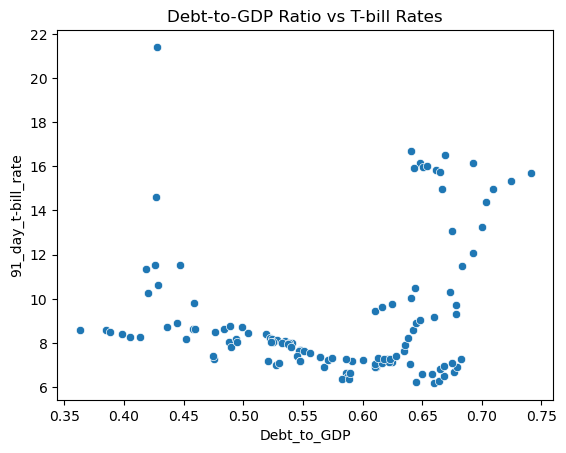

In [67]:
# plotting debt to gdp ratio vs weighted average rate
merged_df['Debt_to_GDP'] = merged_df['total'] / merged_df['nominal_gdp_prices_(ksh_million)']
sns.scatterplot(x='Debt_to_GDP', y='91_day_t-bill_rate', data=merged_df)
plt.title("Debt-to-GDP Ratio vs T-bill Rates")
plt.show()

Output interpretation: Non-linear Relationship but rather threshold-dependent. Moderate debt levels are associated with stable rates, but once debt crosses a certain threshold, T-bill rates escalate sharply, signaling heightened risk premiums.

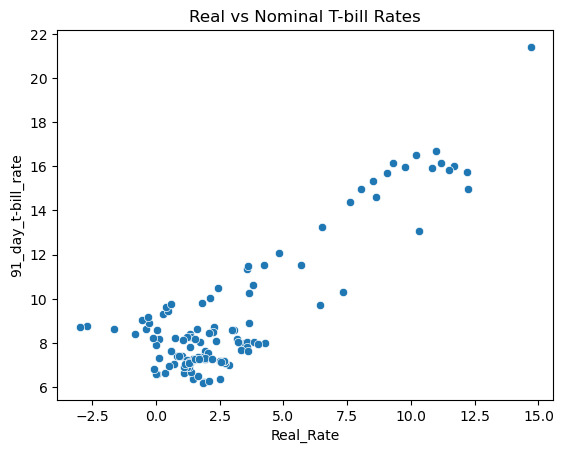

In [68]:
#plotting real vs nominal t-bill rates
merged_df['Real_Rate'] = merged_df['91_day_t-bill_rate'] - merged_df['12month_inflation']
sns.scatterplot(x='Real_Rate', y='91_day_t-bill_rate', data=merged_df)
plt.title("Real vs Nominal T-bill Rates")
plt.show()

Output interpretation:
* Nominal and real T-bill rates are positively correlated.
* For the clusters, most auctions occurred under low real rate conditions, but spikes in real returns happened in special periods.
* CBK seems to adjust nominal rates partly in response to inflation, but other market pressures create variation.